# Steepest Streets

Aug '25+  
Apr '26: Added improvements  
Sep '26: Post improvements to repo

Originally based on https://github.com/gboeing/osmnx-examples/blob/main/notebooks/12-node-elevations-edge-grades.ipynb

Aims to be runnable end-to-end (run all cells) with any valid place query

In [1]:
# Works with .conda Python 3.11.13 in VS Code

%pip install osmnx[all] # Main library
%pip install python-dotenv # For retrieving API key as environment variable

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox
import pandas as pd
import numpy as np

ox.__version__

'2.0.6'

## Settings

API key from `.env` file

In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv('API_KEY') # API key for Google Elevation API

Places: uncomment one or write own

In [4]:
# Can check places on https://nominatim.openstreetmap.org/ui/search.html

# Bay Area small

place_query = {"city": "Millbrae", "state": "California", "country": "USA"}
#place_query = {"city": "Burlingame", "state": "California", "country": "USA"}
#place_query = {"city": "Palo Alto", "state": "California", "country": "USA"}
#place_query = {"city": "San Bruno", "state": "California", "country": "USA"}
#place_query = {"city": "Brisbane", "state": "California", "country": "USA"}
#place_query = {"city": "Foster City", "state": "California", "country": "USA"} # Fails for top 10 with 2 zero gradients
#place_query = {"city": "South San Francisco", "state": "California", "country": "USA"}
#place_query = {"city": "Colma", "state": "California", "country": "USA"}
#place_query = {"city": "Hillsborough", "state": "California", "country": "USA"}

# More: Pacifica, Daly City, San Mateo, Redwood City, Menlo Park, East Palo Alto, Atherton, Portola Valley, Woodside, Half Moon Bay, San Carlos, Belmont

# Bay Area large

#place_query = {"city": "San Francisco", "state": "California", "country": "USA"} # GME API shows example of steepest streets being artifacts due to node location being on hillside. Rank 20 Day Street may be real. Filbert Street between Hyde and Leavenworth is rank 94.

# England small

#place_query = {"city": "Ecclesall", "county": "South Yorkshire", "country": "United Kingdom"} # No polygon
#place_query = {"city": "Ringinglow", "county": "South Yorkshire", "country": "United Kingdom"} # No polygon
#place_query = {"city": "Fulwood", "county": "South Yorkshire", "country": "United Kingdom"} # No polygon

# England large

#place_query = {"city": "Sheffield", "county": "South Yorkshire", "country": "United Kingdom"} # Finds but might be too large for single graph_from_place() call

In [5]:
# Get the place name for usage below, e.g., labeling plots

place = place_query.get("city")
place

'Millbrae'

## Elevation

Get the street network, add elevation to each of the nodes, then calculate edge grades

- Open Topo and Google Maps Elevation return different "steepest streets"
- Open Topo is free but is slow
- Google Maps Elevation runs better but needs the API key

### Open Topo Data

In [6]:
# Commented, but kept to illustrate Open Topo usage

# G = ox.graph.graph_from_place(place_query, network_type="drive")
# original_elevation_url = ox.settings.elevation_url_template
# ox.settings.elevation_url_template = (
#     "https://api.opentopodata.org/v1/aster30m?locations={locations}"
# )
# G = ox.elevation.add_node_elevations_google(G, batch_size=100, pause=1)
# G = ox.elevation.add_edge_grades(G)
# ox.settings.elevation_url_template = original_elevation_url

### Or Google Maps Elevation API

In [7]:
# Google Cloud -> APIs & Services -> Credentials -> Create Credentials -> API key

# Do as try except to avoid OSMnx erroring out if place query is too large for graph_from_place() call, or there is no polygon available.
# If graph_from_place() fails, try graph_from_address() with a radius around the center of the place.
# AI code and comments, modified

try:
    G = ox.graph_from_place(place_query, network_type="drive")
except Exception as e:
    # Convert place_query dict to string for graph_from_address()
    dist = 1000
    place_query_str = ", ".join(place_query.values())
    print(f"graph_from_place() failed with error:")
    print(f"{e}")
    print(f"Trying graph_from_address() for {place_query_str} with radius {dist}")
    G = ox.graph_from_address(place_query_str, dist=dist, network_type="drive")

In [8]:
G = ox.elevation.add_node_elevations_google(G, api_key=api_key)
G = ox.elevation.add_edge_grades(G) # These are the steepnesses of the streets

In [9]:
# Grades are different between the 2, but don't know which is correct
# graph_to_gdfs() allows viewing the geodataframe

ox.graph_to_gdfs(G, nodes=False, edges=True, node_geometry=False, fill_edge_geometry=True)

osmid         highway  \
u          v          key                                                       
65347908   1437411616 0                               8919815     residential   
65348736   9038184249 0                              96026495       secondary   
           339426411  0                             256400261        tertiary   
65358746   65513505   0                               8941196     residential   
65367442   339426148  0     [725124600, 396967406, 725124599]       secondary   
...                                                       ...             ...   
9038184239 911850791  0                             976697779  secondary_link   
           339426411  0    [976697784, 389133512, 1156968359]        tertiary   
9038184249 6777837038 0                             976697781       secondary   
           911850791  0                             997079717       secondary   
9104426312 911155541  0                            1155278281    unclassified   

                                           name  oneway reversed      length  \
u          v          key                                                      
65347908   1437411616 0      Spring Valley Lane   False     True  166.454188   
65348736   9038184249 0    East Millbrae Avenue    True    False    9.994120   
           339426411  0    South McDonnell Road    True    False   43.619099   
65358746   65513505   0           Terrace Drive   False     True  269.931221   
65367442   339426148  0    East Millbrae Avenue    True    False   57.187790   
...                                         ...     ...      ...         ...   
9038184239 911850791  0                     NaN    True    False  107.322088   
           339426411  0    South McDonnell Road   False    False   67.417709   
9038184249 6777837038 0    Old Bayshore Highway    True    False   10.970415   
           911850791  0    East Millbrae Avenue    True    False   21.526329   
9104426312 911155541  0            Rollins Road   False     True   22.250056   

                                                                    geometry  \
u          v          key                                                      
65347908   1437411616 0    LINESTRING (-122.40307 37.59015, -122.40371 37...   
65348736   9038184249 0    LINESTRING (-122.3772 37.60487, -122.37725 37....   
           339426411  0    LINESTRING (-122.3772 37.60487, -122.37727 37....   
65358746   65513505   0    LINESTRING (-122.4228 37.60707, -122.42269 37....   
65367442   339426148  0    LINESTRING (-122.37772 37.6041, -122.3776 37.6...   
...                                                                      ...   
9038184239 911850791  0    LINESTRING (-122.37829 37.60467, -122.37824 37...   
           339426411  0    LINESTRING (-122.37829 37.60467, -122.37816 37...   
9038184249 6777837038 0    LINESTRING (-122.37725 37.60479, -122.37714 37...   
           911850791  0    LINESTRING (-122.37725 37.60479, -122.37737 37...   
9104426312 911155541  0    LINESTRING (-122.38539 37.60202, -122.38534 37...   

                              grade  grade_abs   lanes maxspeed  ref bridge  \
u          v          key                                                     
65347908   1437411616 0   -0.018899   0.018899     NaN      NaN  NaN    NaN   
65348736   9038184249 0   -0.002414   0.002414       2      NaN  NaN    NaN   
           339426411  0    0.000743   0.000743       2   35 mph  NaN    NaN   
65358746   65513505   0   -0.075782   0.075782     NaN      NaN  NaN    NaN   
65367442   339426148  0    0.002912   0.002912  [3, 2]   35 mph  NaN    NaN   
...                             ...        ...     ...      ...  ...    ...   
9038184239 911850791  0   -0.001985   0.001985       1      NaN  NaN    NaN   
           339426411  0    0.006091   0.006091       3   35 mph  NaN    NaN   
9038184249 6777837038 0    0.002604   0.002604     NaN      NaN  NaN    NaN   
           911850791  0   -0.026349   0.026349     

## Plot the nodes by elevation

Plot them colored from low (violet) to high (yellow).

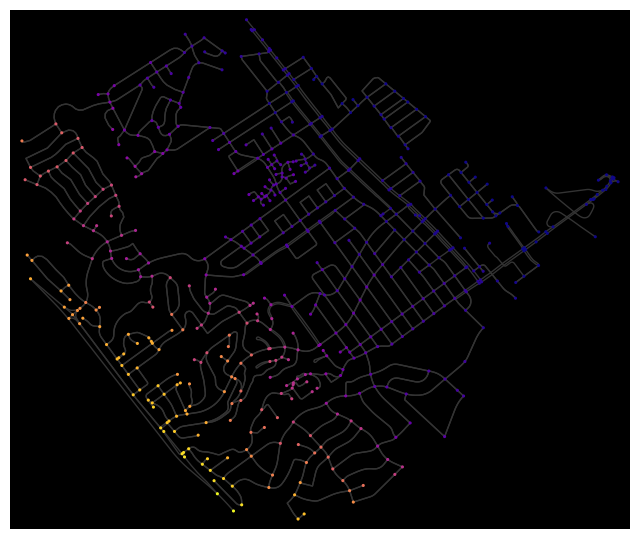

In [10]:
# Get one color for each node, by elevation, then plot the network
# Elevations are relative, not absolute, so the color range will be spanned for both flat and hilly areas

nc = ox.plot.get_node_colors_by_attr(G, "elevation", cmap="plasma")
fig, ax = ox.plot.plot_graph(G, node_color=nc, node_size=5, edge_color="#333333", bgcolor="k")

## Plot the edges by grade

Grade is the ratio of elevation change to edge length. Plot edges colored from low/flat (violet) to high/steep (yellow).

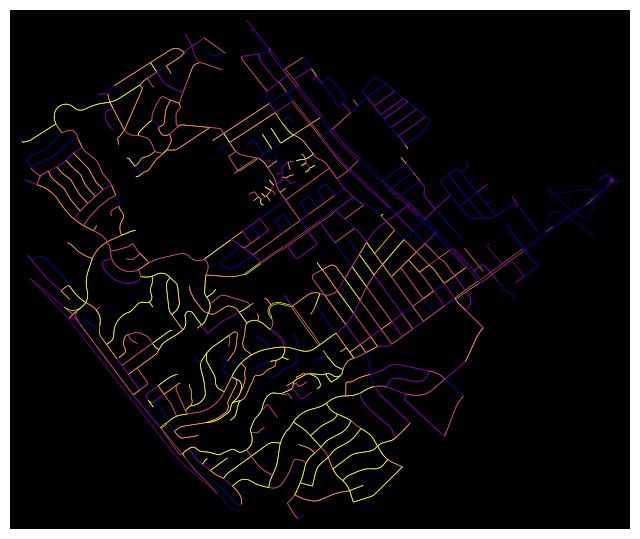

In [11]:
# Get a color for each edge, by grade, then plot the network
# Like elevations, grades are relative and not absolute: equal_size True is quantiles, false is fixed equal width bins
# OSMnx lacks an option to specify given bin edges: https://github.com/gboeing/osmnx/blob/6bc7885526691d662d7d68e153d023b1f512495b/osmnx/plot.py#L867
# Fails if 2 bin edges are the same, which can happen if there are many edges with 0 grade, e.g., Foster City, CA

ec = ox.plot.get_edge_colors_by_attr(G, "grade_abs", cmap="plasma", num_bins=5, equal_size=True)
fig, ax = ox.plot.plot_graph(G, edge_color=ec, edge_linewidth=0.5, node_size=0, bgcolor="k")

## Which street is steepest?

In [12]:
# Calculate the edges' absolute grades (and drop any infinite/null values)

grades = pd.Series([d["grade_abs"] for _, _, d in ox.convert.to_undirected(G).edges(data=True)])
grades = grades.replace([np.inf, -np.inf], np.nan).dropna()

In [13]:
# AI code from section title "Which street is steepest?"
# Only shows index of street with steepest grade, not the name

grades.sort_values(ascending=False, inplace=True)
#place = place_query.get("city")

print(f"The steepest street in {place} is {grades.index[0]} with a grade of {grades.iloc[0] * 100:.1f}%")
print(f"The steepest 10 streets in {place} are:")
print(grades.head(10).to_string())

The steepest street in Millbrae is 313 with a grade of 18.3%
The steepest 10 streets in Millbrae are:
313    0.182650
775    0.174518
776    0.164505
335    0.159133
575    0.158632
469    0.157830
290    0.156859
143    0.154483
569    0.152351
520    0.151433


In [14]:
# View original MultiDiGraph information, converted to geodataframe

gdf = ox.graph_to_gdfs(G, nodes=False, edges=True, node_geometry=False, fill_edge_geometry=True) # AI: Convert the graph to a GeoDataFrame
gdf

osmid         highway  \
u          v          key                                                       
65347908   1437411616 0                               8919815     residential   
65348736   9038184249 0                              96026495       secondary   
           339426411  0                             256400261        tertiary   
65358746   65513505   0                               8941196     residential   
65367442   339426148  0     [725124600, 396967406, 725124599]       secondary   
...                                                       ...             ...   
9038184239 911850791  0                             976697779  secondary_link   
           339426411  0    [976697784, 389133512, 1156968359]        tertiary   
9038184249 6777837038 0                             976697781       secondary   
           911850791  0                             997079717       secondary   
9104426312 911155541  0                            1155278281    unclassified   

                                           name  oneway reversed      length  \
u          v          key                                                      
65347908   1437411616 0      Spring Valley Lane   False     True  166.454188   
65348736   9038184249 0    East Millbrae Avenue    True    False    9.994120   
           339426411  0    South McDonnell Road    True    False   43.619099   
65358746   65513505   0           Terrace Drive   False     True  269.931221   
65367442   339426148  0    East Millbrae Avenue    True    False   57.187790   
...                                         ...     ...      ...         ...   
9038184239 911850791  0                     NaN    True    False  107.322088   
           339426411  0    South McDonnell Road   False    False   67.417709   
9038184249 6777837038 0    Old Bayshore Highway    True    False   10.970415   
           911850791  0    East Millbrae Avenue    True    False   21.526329   
9104426312 911155541  0            Rollins Road   False     True   22.250056   

                                                                    geometry  \
u          v          key                                                      
65347908   1437411616 0    LINESTRING (-122.40307 37.59015, -122.40371 37...   
65348736   9038184249 0    LINESTRING (-122.3772 37.60487, -122.37725 37....   
           339426411  0    LINESTRING (-122.3772 37.60487, -122.37727 37....   
65358746   65513505   0    LINESTRING (-122.4228 37.60707, -122.42269 37....   
65367442   339426148  0    LINESTRING (-122.37772 37.6041, -122.3776 37.6...   
...                                                                      ...   
9038184239 911850791  0    LINESTRING (-122.37829 37.60467, -122.37824 37...   
           339426411  0    LINESTRING (-122.37829 37.60467, -122.37816 37...   
9038184249 6777837038 0    LINESTRING (-122.37725 37.60479, -122.37714 37...   
           911850791  0    LINESTRING (-122.37725 37.60479, -122.37737 37...   
9104426312 911155541  0    LINESTRING (-122.38539 37.60202, -122.38534 37...   

                              grade  grade_abs   lanes maxspeed  ref bridge  \
u          v          key                                                     
65347908   1437411616 0   -0.018899   0.018899     NaN      NaN  NaN    NaN   
65348736   9038184249 0   -0.002414   0.002414       2      NaN  NaN    NaN   
           339426411  0    0.000743   0.000743       2   35 mph  NaN    NaN   
65358746   65513505   0   -0.075782   0.075782     NaN      NaN  NaN    NaN   
65367442   339426148  0    0.002912   0.002912  [3, 2]   35 mph  NaN    NaN   
...                             ...        ...     ...      ...  ...    ...   
9038184239 911850791  0   -0.001985   0.001985       1      NaN  NaN    NaN   
           339426411  0    0.006091   0.006091       3   35 mph  NaN    NaN   
9038184249 6777837038 0    0.002604   0.002604     NaN      NaN  NaN    NaN   
           911850791  0   -0.026349   0.026349     

In [15]:
gdf.get_coordinates()

x          y
u          v          key                       
65347908   1437411616 0   -122.403072  37.590145
                      0   -122.403707  37.590854
                      0   -122.403790  37.590932
                      0   -122.403838  37.590943
                      0   -122.403879  37.590937
...                               ...        ...
9038184249 911850791  0   -122.377252  37.604786
                      0   -122.377374  37.604618
9104426312 911155541  0   -122.385390  37.602018
                      0   -122.385340  37.601910
                      0   -122.385282  37.601839

[8321 rows x 2 columns]

In [16]:
# Shows has the street names, so we want the undirected and cleaned "grades" series but retaining the other columns

grades_gdf = gpd.GeoDataFrame([d for _, _, d in ox.convert.to_undirected(G).edges(data=True)])
grades_gdf

,osmid,highway,name,oneway,reversed,length,geometry,grade,grade_abs,from,to,lanes,maxspeed,ref,bridge,tunnel
0,8919815,residential,Spring Valley Lane,False,False,166.454188,"LINESTRING (-122.40429 37.59063, -122.40418 37...",0.018899,0.018899,1437411616,65347908,NaN,NaN,NaN,NaN,NaN
1,96026495,secondary,East Millbrae Avenue,True,False,9.994120,"LINESTRING (-122.3772 37.60487, -122.37725 37....",-0.002414,0.002414,65348736,9038184249,2,NaN,NaN,NaN,NaN
2,256400261,tertiary,South McDonnell Road,True,False,43.619099,"LINESTRING (-122.3772 37.60487, -122.37727 37....",0.000743,0.000743,65348736,339426411,2,35 mph,NaN,NaN,NaN
3,517255694,secondary,Old Bayshore Highway,True,False,11.209483,"LINESTRING (-122.37709 37.60482, -122.3772 37....",-0.003382,0.003382,1112549612,65348736,3,35 mph,NaN,NaN,NaN
4,8941196,residential,Terrace Drive,False,False,269.931221,"LINESTRING (-122.42017 37.60811, -122.42217 37...",0.075782,0.075782,65513505,65358746,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
789,976697781,secondary,Old Bayshore Highway,True,False,10.970415,"LINESTRING (-122.37725 37.60479, -122.37714 37...",0.002604,0.002604,9038184249,6777837038,NaN,NaN,NaN,NaN,NaN
790,395651962,motorway_link,NaN,True,False,16.898154,"LINESTRING (-122.3787 37.60349, -122.37889 37....",0.015395,0.015395,6777837039,6777837040,2,NaN,NaN,NaN,NaN
791,776133833,residential,NaN,False,True,30.853110,"LINESTRING (-122.40404 37.60366, -122.40415 37...",0.079959,0.079959,7241522647,7241522645,NaN,NaN,NaN,NaN,NaN
792,783916996,residential,NaN,False,True,42.804218,"LINESTRING (-122.40351 37.60562, -122.40379 37...",0.017192,0.017192,7322322958,7322322957,NaN,NaN,NaN,NaN,NaN


In [17]:
grades_gdf.get_coordinates()

,x,y
0,-122.404286,37.590631
0,-122.404180,37.590671
0,-122.404082,37.590737
0,-122.404013,37.590825
0,-122.403950,37.590888
...,...,...
791,-122.404281,37.603854
792,-122.403510,37.605625
792,-122.403786,37.605941
793,-122.403286,37.605368


In [18]:
# Check for NaN grades

nan_count = grades_gdf["grade_abs"].isna().sum()
print(nan_count)

0


In [19]:
# Check for infinite grades

inf_count = np.isinf(grades_gdf["grade_abs"]).sum()
print(inf_count)

0


In [20]:
# If there are, we would need a line like
# grades_gdf["grade_abs"].replace([np.inf, -np.inf], np.nan).dropna()
# but for the gdf
# Cf. gdf = gdf[gdf["grade_abs"].notna()] from https://codeberg.org/linesinalandscape/my-osmnx-scripts/src/branch/main/steep_street_finder.py

In [21]:
# Sort the dataframe in descending order by absolute grade to find the steepest streets

grades_gdf_sorted = grades_gdf.sort_values(by='grade_abs', ascending=False)
grades_gdf_sorted.head(10)

,osmid,highway,name,oneway,reversed,length,geometry,grade,grade_abs,from,to,lanes,maxspeed,ref,bridge,tunnel
313,8936197,residential,Mullins Court,False,False,64.813182,"LINESTRING (-122.40658 37.59101, -122.40652 37...",-0.182650,0.182650,65452706,65415733,2,25 mph,NaN,NaN,NaN
775,129390194,tertiary,Hillcrest Boulevard,False,True,11.216886,"LINESTRING (-122.39987 37.59456, -122.39977 37...",-0.174518,0.174518,1437496830,1437496701,2,NaN,NaN,NaN,NaN
776,129390194,tertiary,Hillcrest Boulevard,False,True,9.862952,"LINESTRING (-122.40374 37.59436, -122.40363 37...",-0.164505,0.164505,1437496743,1437496725,2,NaN,NaN,NaN,NaN
335,262874277,tertiary,Larkspur Drive,False,True,307.163761,"LINESTRING (-122.41787 37.59719, -122.4178 37....",-0.159133,0.159133,65416557,65416554,2,NaN,NaN,NaN,NaN
575,8932599,residential,Lower Vista Grande,False,True,105.957466,"LINESTRING (-122.40589 37.59177, -122.40585 37...",0.158632,0.158632,65452702,65451911,NaN,NaN,NaN,NaN,NaN
469,130548101,residential,El Bonito Way,False,False,77.513361,"LINESTRING (-122.4046 37.59607, -122.40475 37....",0.157830,0.157830,65436588,65436577,NaN,NaN,NaN,NaN,NaN
290,129390194,tertiary,Hillcrest Boulevard,False,False,125.929466,"LINESTRING (-122.40374 37.59436, -122.40397 37...",0.156859,0.156859,1437496743,65415631,2,NaN,NaN,NaN,NaN
143,45842206,residential,Camino Alto,True,False,236.028369,"LINESTRING (-122.40351 37.5962, -122.40353 37....",-0.154483,0.154483,418088968,65398856,NaN,NaN,NaN,NaN,NaN
569,8932510,residential,Vista Grande,False,True,363.583438,"LINESTRING (-122.40898 37.59353, -122.409 37.5...",0.152351,0.152351,65451895,65451890,2,25 mph,NaN,NaN,NaN
520,130536466,residential,La Prenda,False,True,154.617706,"LINESTRING (-122.41079 37.59279, -122.41087 37...",0.151433,0.151433,267292688,65441942,2,25 mph,NaN,NaN,NaN


In [22]:
# Threshold the street lengths to exclude very short streets that may have artificially high grades due to node location on a hillside
# AI code

min_length = 50  # Meters

grades_gdf_sorted = grades_gdf_sorted[grades_gdf_sorted['length'] >= min_length]
grades_gdf_sorted.head(10)

,osmid,highway,name,oneway,reversed,length,geometry,grade,grade_abs,from,to,lanes,maxspeed,ref,bridge,tunnel
313,8936197,residential,Mullins Court,False,False,64.813182,"LINESTRING (-122.40658 37.59101, -122.40652 37...",-0.182650,0.182650,65452706,65415733,2,25 mph,NaN,NaN,NaN
335,262874277,tertiary,Larkspur Drive,False,True,307.163761,"LINESTRING (-122.41787 37.59719, -122.4178 37....",-0.159133,0.159133,65416557,65416554,2,NaN,NaN,NaN,NaN
575,8932599,residential,Lower Vista Grande,False,True,105.957466,"LINESTRING (-122.40589 37.59177, -122.40585 37...",0.158632,0.158632,65452702,65451911,NaN,NaN,NaN,NaN,NaN
469,130548101,residential,El Bonito Way,False,False,77.513361,"LINESTRING (-122.4046 37.59607, -122.40475 37....",0.157830,0.157830,65436588,65436577,NaN,NaN,NaN,NaN,NaN
290,129390194,tertiary,Hillcrest Boulevard,False,False,125.929466,"LINESTRING (-122.40374 37.59436, -122.40397 37...",0.156859,0.156859,1437496743,65415631,2,NaN,NaN,NaN,NaN
143,45842206,residential,Camino Alto,True,False,236.028369,"LINESTRING (-122.40351 37.5962, -122.40353 37....",-0.154483,0.154483,418088968,65398856,NaN,NaN,NaN,NaN,NaN
569,8932510,residential,Vista Grande,False,True,363.583438,"LINESTRING (-122.40898 37.59353, -122.409 37.5...",0.152351,0.152351,65451895,65451890,2,25 mph,NaN,NaN,NaN
520,130536466,residential,La Prenda,False,True,154.617706,"LINESTRING (-122.41079 37.59279, -122.41087 37...",0.151433,0.151433,267292688,65441942,2,25 mph,NaN,NaN,NaN
139,8925667,residential,Camino Alto,True,False,151.878380,"LINESTRING (-122.40195 37.59694, -122.40203 37...",0.149224,0.149224,65398856,583444299,NaN,NaN,NaN,NaN,NaN
660,8937338,residential,Clearfield Drive,False,True,276.520794,"LINESTRING (-122.41038 37.59552, -122.41027 37...",-0.148998,0.148998,65488929,65488921,2,25 mph,NaN,NaN,NaN


In [23]:
print(f'The steepest street in {place} is {grades_gdf_sorted["name"].values[0]} with a grade of {grades_gdf_sorted["grade_abs"].values[0] * 100:.1f}%')

The steepest street in Millbrae is Mullins Court with a grade of 18.3%


## See the steepest street on the map

Or the nth steepest. View some of the data values as a santy check.

In [24]:
# Street rank to see
# 1 = steepest, 2 = second steepest, etc.

rank = 1

In [25]:
grades_gdf_sorted["geometry"]

313    LINESTRING (-122.40658 37.59101, -122.40652 37...
335    LINESTRING (-122.41787 37.59719, -122.4178 37....
575    LINESTRING (-122.40589 37.59177, -122.40585 37...
469    LINESTRING (-122.4046 37.59607, -122.40475 37....
290    LINESTRING (-122.40374 37.59436, -122.40397 37...
                             ...                        
50     LINESTRING (-122.39588 37.5928, -122.39584 37....
580    LINESTRING (-122.39374 37.60736, -122.39379 37...
649    LINESTRING (-122.40416 37.60624, -122.40489 37...
643    LINESTRING (-122.39926 37.59393, -122.40016 37...
774    LINESTRING (-122.40365 37.59358, -122.40379 37...
Name: geometry, Length: 646, dtype: geometry

In [26]:
c = grades_gdf_sorted.get_coordinates()
c

,x,y
313,-122.406583,37.591007
313,-122.406515,37.591054
313,-122.406436,37.591088
313,-122.406342,37.591111
313,-122.405898,37.591198
...,...,...
774,-122.404183,37.593423
774,-122.404033,37.593474
774,-122.403886,37.593512
774,-122.403776,37.593544


In [27]:
c['x'][grades_gdf_sorted.index[rank-1]]

313   -122.406583
313   -122.406515
313   -122.406436
313   -122.406342
313   -122.405898
Name: x, dtype: float64

In [28]:
c['y'][grades_gdf_sorted.index[rank-1]]

313    37.591007
313    37.591054
313    37.591088
313    37.591111
313    37.591198
Name: y, dtype: float64

In [29]:
x_origin = c['x'][grades_gdf_sorted.index[rank-1]].values[0]
y_origin = c['y'][grades_gdf_sorted.index[rank-1]].values[0]
x_dest = c['x'][grades_gdf_sorted.index[rank-1]].values[-1]
y_dest = c['y'][grades_gdf_sorted.index[rank-1]].values[-1]

x_mean = (x_origin + x_dest) / 2
y_mean = (y_origin + y_dest) / 2

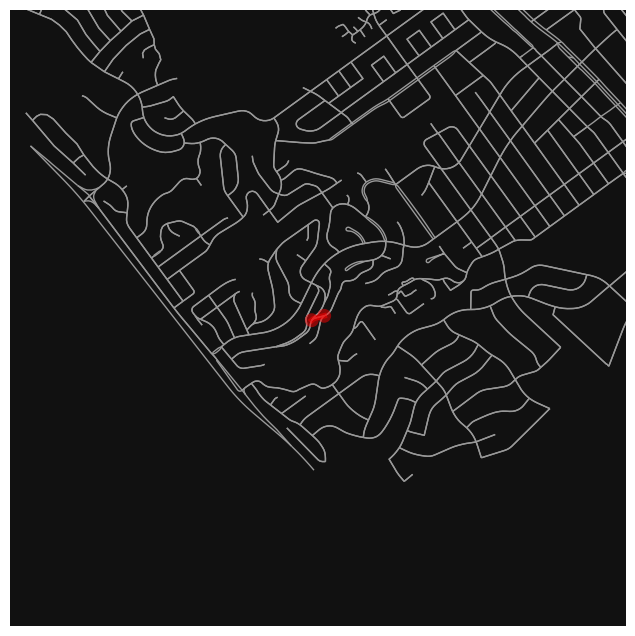

In [30]:
# Copying the route-finding code from 12-node-elevations-edge-grades.ipynb
# Better might be plot the edge directly
# Could also plot whole city using its bbox instead of zoom with street at center

origin = ox.distance.nearest_nodes(G, x_origin, y_origin)
destination = ox.distance.nearest_nodes(G, x_dest, y_dest)
bbox = ox.utils_geo.bbox_from_point((y_mean, x_mean), dist=1500)

route_by_length = ox.routing.shortest_path(G, origin, destination, weight="length")
fig, ax = ox.plot.plot_graph_route(G, route_by_length, bbox=bbox, node_size=0)

## Top N steepest streets

NEW Apr '26

In [31]:
# NEW Apr '26: Function to get route and bbox for given street rank

def get_route_by_length(rank):
    c = grades_gdf_sorted.get_coordinates()
    
    x_origin = c['x'][grades_gdf_sorted.index[rank-1]].values[0]
    y_origin = c['y'][grades_gdf_sorted.index[rank-1]].values[0]
    x_dest = c['x'][grades_gdf_sorted.index[rank-1]].values[-1]
    y_dest = c['y'][grades_gdf_sorted.index[rank-1]].values[-1]

    x_mean = (x_origin + x_dest) / 2
    y_mean = (y_origin + y_dest) / 2
    
    origin = ox.distance.nearest_nodes(G, x_origin, y_origin)
    destination = ox.distance.nearest_nodes(G, x_dest, y_dest)
    bbox = ox.utils_geo.bbox_from_point((y_mean, x_mean), dist=1500)

    route_by_length = ox.routing.shortest_path(G, origin, destination, weight="length")

    return route_by_length, bbox

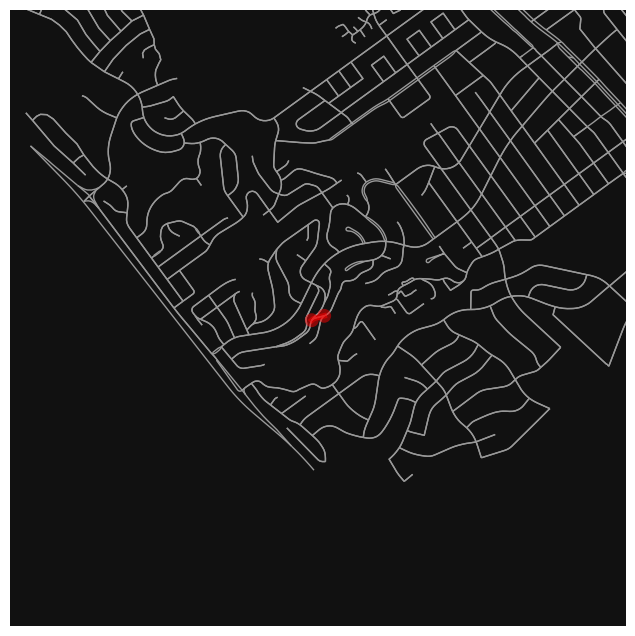

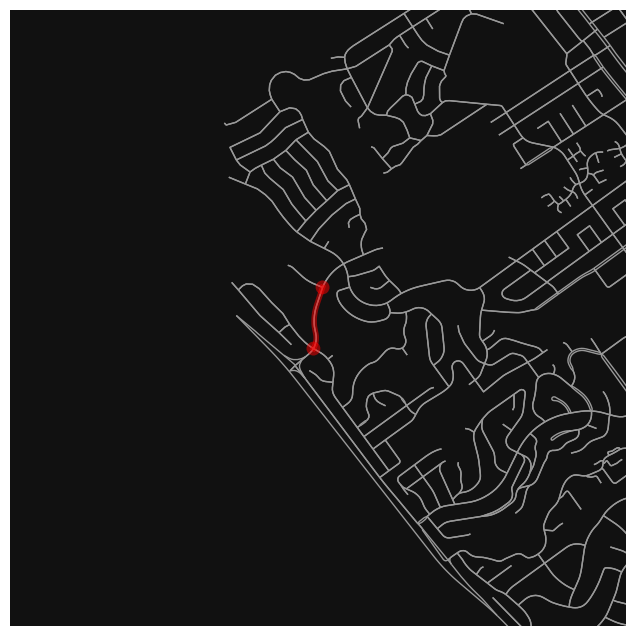

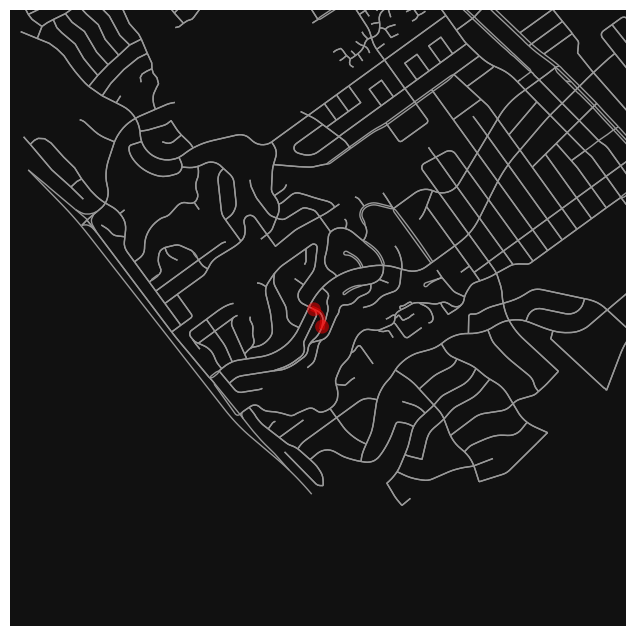

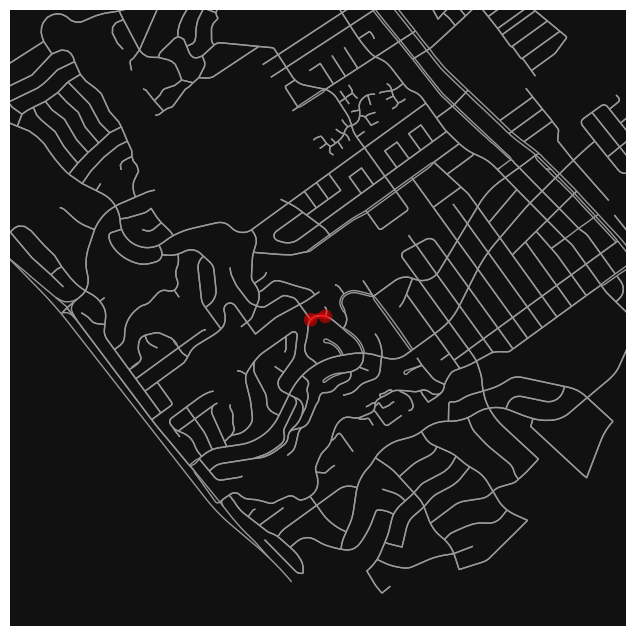

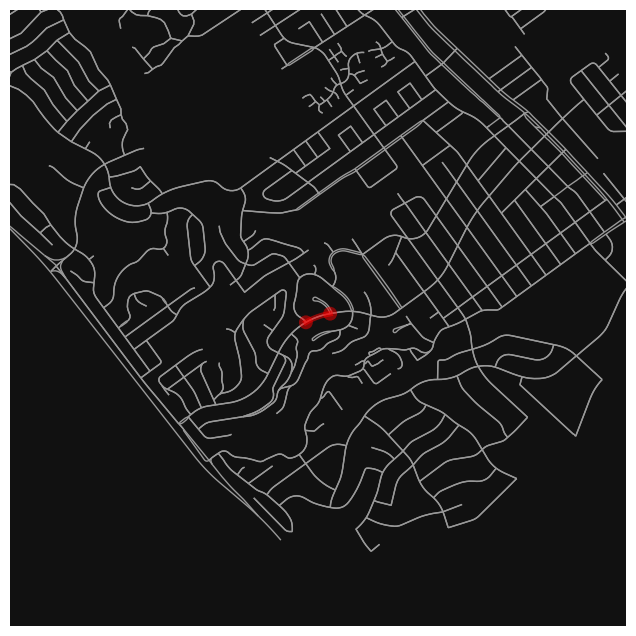

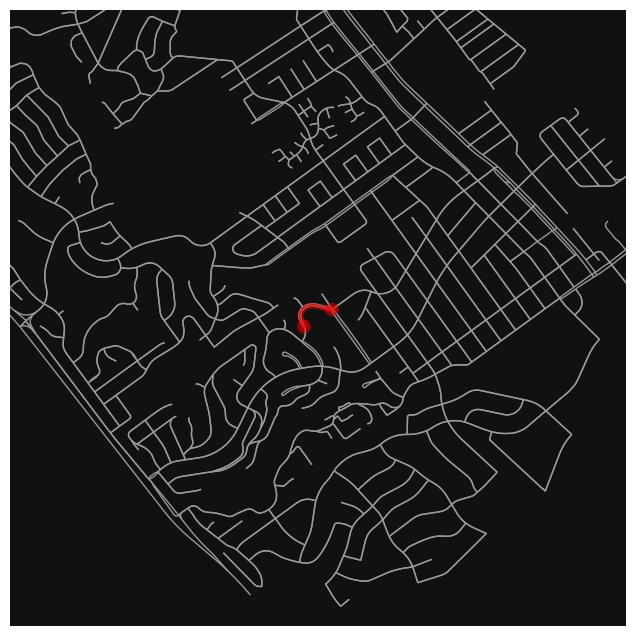

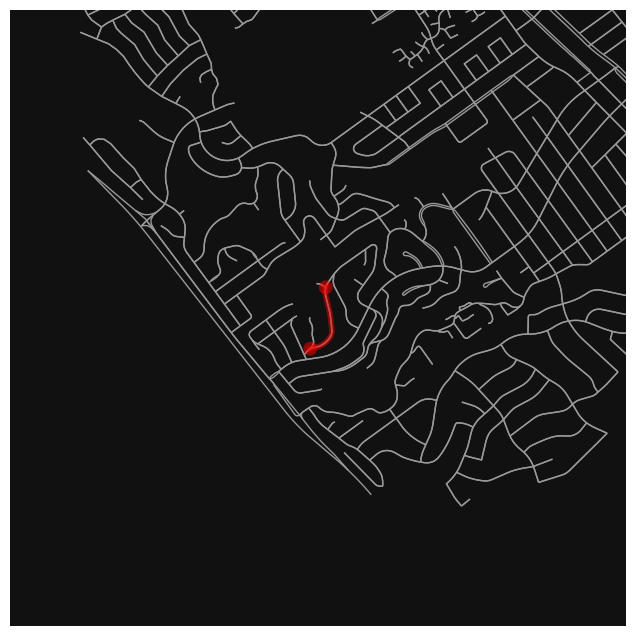

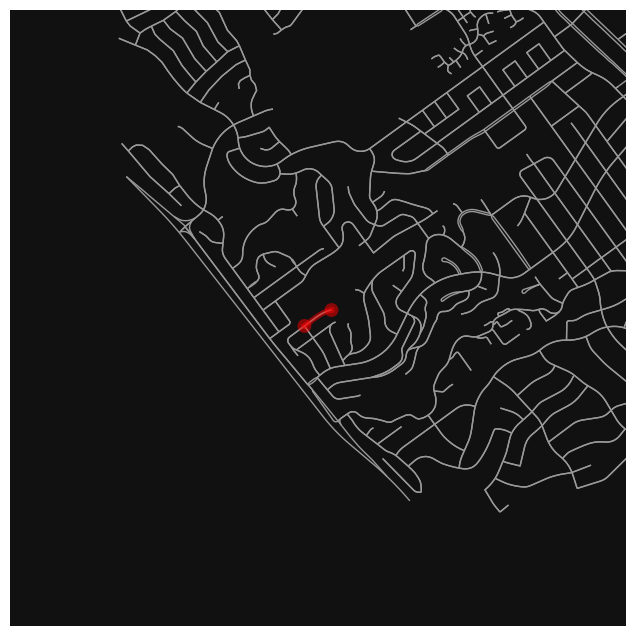

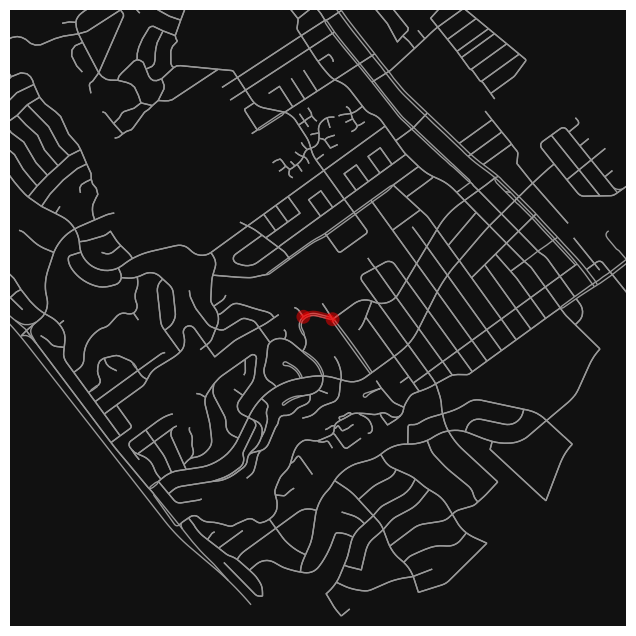

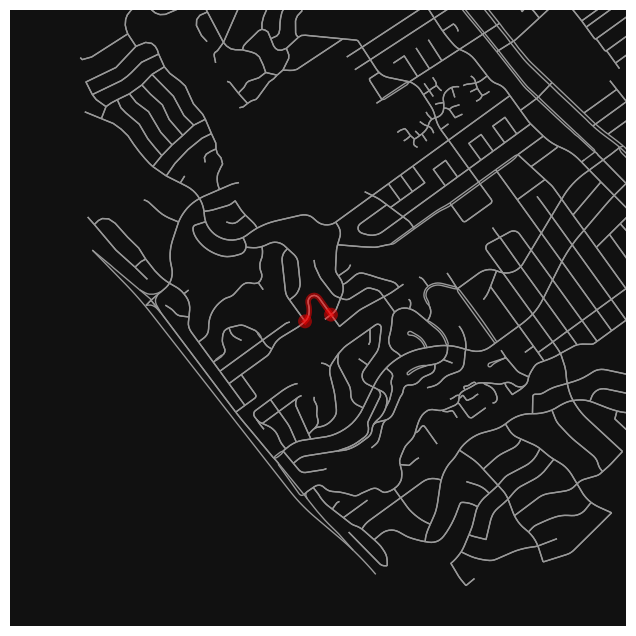

In [32]:
# NEW Apr '26: Plot route(s) for given street rank range in separate plots using plot_graph_route()

min_rank = 1
max_rank = 10

for irank in range(min_rank, max_rank + 1):
    route_by_length, bbox = get_route_by_length(irank)
    fig, ax = ox.plot.plot_graph_route(G, route_by_length, bbox=bbox, node_size=0)

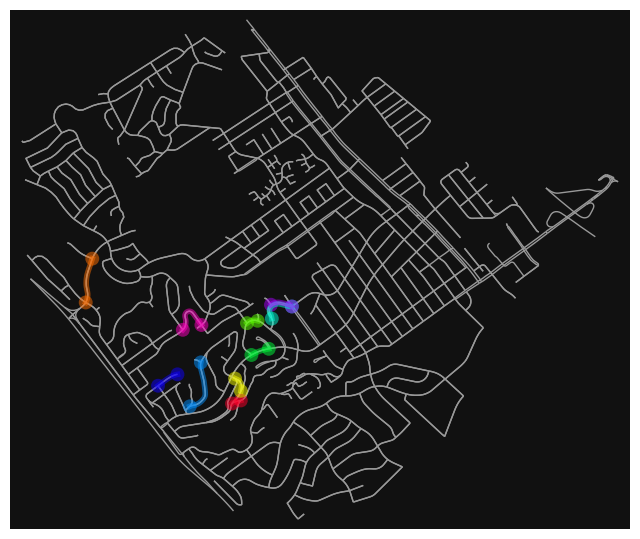

In [33]:
# NEW Apr '26: plot_graph_routes() takes list of routes
# AI code, modified

# Get list of routes and bboxes for given street rank range

min_rank = 1
max_rank = 10
routes = []
bboxes = []

for irank in range(min_rank, max_rank + 1):
    route_by_length, bbox = get_route_by_length(irank)
    routes.append(route_by_length)
    bboxes.append(bbox)

# Get list of strings from given matplotlibcolormap (default viridis) for the routes
# E.g., https://matplotlib.org/stable/users/explain/colors/colormaps.html

route_colors = ox.plot.get_colors(n=len(routes), cmap="gist_rainbow", start=0.0, stop=1.0)

# Plot all routes in one plot, colored by rank
# Uses bbox for whole network

fig, ax = ox.plot.plot_graph_routes(G, routes, route_colors=route_colors, node_size=0)

In [34]:
# Interactive map
# Doesn't highlight the steepest street, but can zoom in on it

#ox.convert.graph_to_gdfs(G, nodes=False).explore()

In [35]:
# Steepest street on base map with start and end nodes marked
# Shows if these nodes are correct and not, e.g., on a hillside

In [36]:
# Can see from this but want to highlight the particular street

#ox.convert.graph_to_gdfs(G, edges=False).explore()

In [37]:
# Can also see both edges and nodes but similarly want to highlight the particular street
# m is passing the first Folium map to the second explore

#nodes, edges = ox.convert.graph_to_gdfs(G)
#m = edges.explore()
##m = edges.explore(tiles="cartodbpositron")
#nodes.explore(m=m, color="red", marker_kwds={"radius": 6})

In [38]:
# NEW: Convert routes to list of geodataframes
# AI code, modified

import folium

route_gdfs = [ox.routing.route_to_gdf(G, route) for route in routes]

# Add rank to each route geodataframe for use in coloring
for i, route_gdf in enumerate(route_gdfs):
    route_gdf["rank"] = i + 1

# Overlay the route geodataframes onto the same interactive map, colored by rank
# Uses the same route_colors list as above

m = route_gdfs[0].explore(title="Steepest Routes")

for i, route_gdf in enumerate(route_gdfs):
    route_gdf.explore(m=m, color=route_colors[i], name=f"Rank {i+1}")

# Show the map with layer control to toggle routes on and off

m.add_child(folium.LayerControl())
m.save("steepest_routes_map.html")


In [39]:
# Can force redraw/load of the basemap in VS Code notebook by splitting the screen
# View -> Editor Layout -> Split Up/Down, then recombine with View -> Editor Layout -> Single

# Can see just steepest street by doing explore routes, like in notebook 11
# route_by_length = ox.routing.shortest_path(G, origin, destination, weight="length")
# ox.routing.route_to_gdf doesn't show nodes, but the ends of route are always on a node
# To see the nodes on the route, would have to filter G to just the steepest street, then do nodes & edges explore
# The nodes appear to always match the streets, but the street view with pitch below usually shows if the gradient is an artifact, because it is looking up steeper than the street

route_edges = ox.routing.route_to_gdf(G, route_by_length)

route_edges.explore()
#route_edges.explore(tiles="cartodbpositron")
#route_edges.explore(tiles="cartodbdarkmatter")

## Distribution of grades

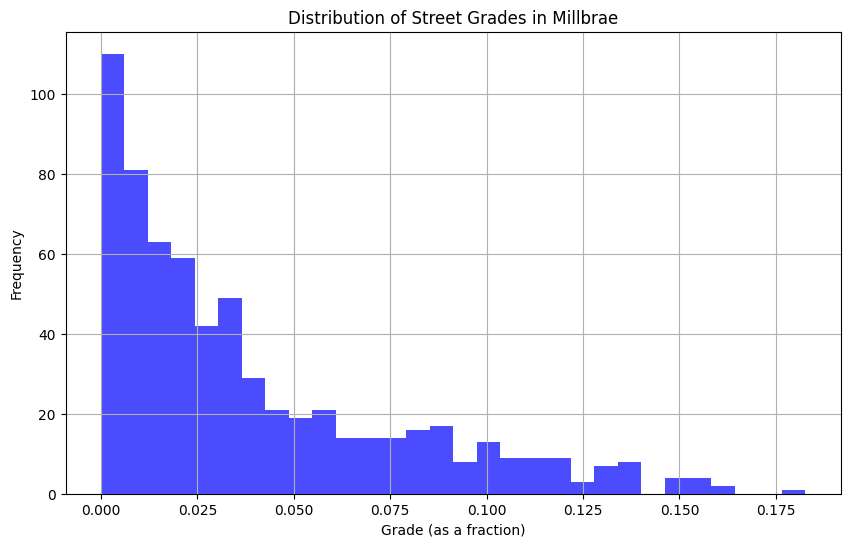

In [40]:
# Plot distribution of grades (AI code + edits)

title = f'Distribution of Street Grades in {place}'

plt.figure(figsize=(10, 6))
plt.hist(grades_gdf_sorted['grade_abs'], bins=30, color='blue', alpha=0.7)
plt.title(title)
plt.xlabel('Grade (as a fraction)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

## Street View of the steepest street

In [41]:
# Want street view of the steepest street, looking uphill from bottom to top
# Need elevations of the start and end points from the original multiDiGraph G

In [42]:
(gdf_nodes,gdf_edges) = ox.graph_to_gdfs(G, nodes=True, edges=True, node_geometry=True, fill_edge_geometry=True)

In [43]:
gdf_nodes

,y,x,street_count,elevation,highway,ref,geometry
osmid,,,,,,,
65347908,37.590145,-122.403072,1,111.359840,NaN,NaN,POINT (-122.40307 37.59015)
65348736,37.604866,-122.377200,3,2.934466,NaN,NaN,POINT (-122.3772 37.60487)
65358746,37.607071,-122.422795,1,128.990021,NaN,NaN,POINT (-122.4228 37.60707)
65367442,37.604098,-122.377719,3,2.038225,NaN,NaN,POINT (-122.37772 37.6041)
65384141,37.600893,-122.383104,3,1.566176,NaN,NaN,POINT (-122.3831 37.60089)
...,...,...,...,...,...,...,...
7322322959,37.605368,-122.403286,1,31.936565,NaN,NaN,POINT (-122.40329 37.60537)
7322322962,37.605619,-122.402823,1,29.369593,NaN,NaN,POINT (-122.40282 37.60562)
9038184239,37.604670,-122.378295,3,2.556232,NaN,NaN,POINT (-122.37829 37.60467)


In [44]:
# Get nodes same as for steepest street plot above
# origin = ox.distance.nearest_nodes(G, x_origin, y_origin) returns the node ID
# Get the node elevations from these

gdf_nodes.loc[origin]

y                                     37.591007
x                                   -122.406583
street_count                                  3
elevation                            128.933914
highway                                     NaN
ref                                         NaN
geometry        POINT (-122.4065827 37.5910067)
Name: 65452706, dtype: object

In [45]:
gdf_nodes.loc[destination]

y                                     37.591198
x                                   -122.405898
street_count                                  3
elevation                            117.095757
highway                                     NaN
ref                                         NaN
geometry        POINT (-122.4058984 37.5911979)
Name: 65415733, dtype: object

In [46]:
el_origin = gdf_nodes.loc[origin].elevation
el_origin

np.float64(128.9339141845703)

In [47]:
el_dest = gdf_nodes.loc[destination].elevation
el_dest

np.float64(117.0957565307617)

In [48]:
# Streetview coordinates are latitude,longitude of the lower elevation point
# Get heading from origin to destination using flat-earth approximation
# Spherical great circle distance is Haversine formula, but flat-earth is close enough for the short distances used here
# Based on AI code but corrected
# May be a shorter code using negative angles but this works

# Set origin and destination for Street View to be the lower and higher elevation points

if el_origin < el_dest:
    lat_dest = gdf_nodes.loc[destination].y
    lon_dest = gdf_nodes.loc[destination].x
    lat_origin = gdf_nodes.loc[origin].y
    lon_origin = gdf_nodes.loc[origin].x
elif el_dest < el_origin:
    lat_dest = gdf_nodes.loc[origin].y
    lon_dest = gdf_nodes.loc[origin].x
    lat_origin = gdf_nodes.loc[destination].y
    lon_origin = gdf_nodes.loc[destination].x
else:
    print('Origin and destination have same elevation, cannot determine heading')
    sys.exit(1)

lon_delta = abs(lon_dest - lon_origin)
lat_delta = abs(lat_dest - lat_origin)

angle = np.degrees(np.arctan2(lon_delta, lat_delta))

# Correct the heading to be in the range 0-360 degrees

if lat_dest > lat_origin and lon_dest > lon_origin: # NE quadrant
    heading = angle
elif lat_dest < lat_origin and lon_dest > lon_origin: # SE quadrant
    heading = 180 - angle
elif lat_dest < lat_origin and lon_dest < lon_origin: # SW quadrant
    heading = 180 + angle
elif lat_dest > lat_origin and lon_dest < lon_origin: # NW quadrant
    heading = 360 - angle
else:
    print('Error in heading calculation')
    sys.exit(1)

print(angle, heading)

74.3891256808822 254.38912568088222


In [49]:
# Calculate the pitch as the angle of elevation from start to end point
# A large pitch >> 10.0 likely indicates a grade artifact such as a node on a hillside
# E.g., Filbert Street between Hyde and Leavenworth in SF is grade 0.2062 and pitch 9.31
# Pitch 0 is another valid view

el_delta = abs(el_dest - el_origin)
d_degrees = np.sqrt(lon_delta**2 + lat_delta**2)
d_meters = 111120 * d_degrees
pitch = np.degrees(np.arctan2(el_delta, d_meters))

print(el_delta, d_degrees, d_meters, pitch)

11.838157653808608 0.0007105096269600455 78.95182974780026 8.527488864617514


In [ ]:
# Streetview URL is like
# https://maps.googleapis.com/maps/api/streetview?size=600x300&location=37.591007,-122.406583&heading=235&pitch=10&key=YOUR_API_KEY
# AI code from comment
# Clicking on URL shows the streetview image

URL = (f'https://maps.googleapis.com/maps/api/streetview?size=600x300&location={lat_origin},{lon_origin}'
       f'&heading={heading:.0f}&pitch={pitch}&key={api_key}')
URL

## Street View: Top 10 URLs

NEW Apr '26: Refactor to functions and loop

In [51]:
# Similar to get_route_by_length() above

def get_origin_destination(rank):
    c = grades_gdf_sorted.get_coordinates()
    
    x_origin = c['x'][grades_gdf_sorted.index[rank-1]].values[0]
    y_origin = c['y'][grades_gdf_sorted.index[rank-1]].values[0]
    x_dest = c['x'][grades_gdf_sorted.index[rank-1]].values[-1]
    y_dest = c['y'][grades_gdf_sorted.index[rank-1]].values[-1]

    origin = ox.distance.nearest_nodes(G, x_origin, y_origin)
    destination = ox.distance.nearest_nodes(G, x_dest, y_dest)

    return origin, destination

In [52]:
def get_heading_lat_long_pitch(el_origin, el_dest):

    # Set origin and destination for Street View to be the lower and higher elevation points

    if el_origin < el_dest:
        lat_dest = gdf_nodes.loc[destination].y
        lon_dest = gdf_nodes.loc[destination].x
        lat_origin = gdf_nodes.loc[origin].y
        lon_origin = gdf_nodes.loc[origin].x
    elif el_dest < el_origin:
        lat_dest = gdf_nodes.loc[origin].y
        lon_dest = gdf_nodes.loc[origin].x
        lat_origin = gdf_nodes.loc[destination].y
        lon_origin = gdf_nodes.loc[destination].x
    else:
        print('Origin and destination have same elevation, cannot determine heading')
        sys.exit(1)

    lon_delta = abs(lon_dest - lon_origin)
    lat_delta = abs(lat_dest - lat_origin)

    angle = np.degrees(np.arctan2(lon_delta, lat_delta))

    # Correct the heading to be in the range 0-360 degrees
    
    if lat_dest > lat_origin and lon_dest > lon_origin: # NE quadrant
        heading = angle
    elif lat_dest < lat_origin and lon_dest > lon_origin: # SE quadrant
        heading = 180 - angle
    elif lat_dest < lat_origin and lon_dest < lon_origin: # SW quadrant
        heading = 180 + angle
    elif lat_dest > lat_origin and lon_dest < lon_origin: # NW quadrant
        heading = 360 - angle
    else:
        print('Error in heading calculation')
        sys.exit(1)

    el_delta = abs(el_dest - el_origin)
    d_degrees = np.sqrt(lon_delta**2 + lat_delta**2)
    d_meters = 111120 * d_degrees
    pitch = np.degrees(np.arctan2(el_delta, d_meters))

    return heading, lat_origin, lon_origin, pitch

In [ ]:
(gdf_nodes, gdf_edges) = ox.graph_to_gdfs(G, nodes=True, edges=True, node_geometry=True, fill_edge_geometry=True)

for rank in range(1, 11):

    origin, destination = get_origin_destination(rank)

    el_origin = gdf_nodes.loc[origin].elevation
    el_dest = gdf_nodes.loc[destination].elevation

    heading, lat_origin, lon_origin, pitch = get_heading_lat_long_pitch(el_origin, el_dest)

    URL = (f'https://maps.googleapis.com/maps/api/streetview?size=600x300&location={lat_origin},{lon_origin}'
        f'&heading={heading:.0f}&pitch={pitch}&key={api_key}')
    print(URL)